# Callbacks

> Event handlers

In [ ]:
#| default_exp callbacks

In [ ]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *
from bonsai.backend import set_backend

In [ ]:
#| export

# ---------------------------------------------------------------------
# Standard library
# ---------------------------------------------------------------------
from abc import ABC, abstractmethod
from contextlib import nullcontext
from typing import Any, Callable, Dict, Optional, Type

# ---------------------------------------------------------------------
# Third-party
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# fastai
# ---------------------------------------------------------------------
from fastai.callback.core import Callback as FastaiCallback, Tensor, range_of
from fastai.callback.schedule import ParamScheduler, SchedCos, SchedExp, SchedLin, SchedNo
from fastai.callback.tracker import (
    EarlyStoppingCallback,
    ReduceLROnPlateau,
    SaveModelCallback,
    ShowGraphCallback as FastaiShowGraphCallback,
)
from fastai.callback.training import GradientAccumulation, ShortEpochCallback
from fastai.vision.all import CSVLogger
# from fastprogress.fastprogress import master_bar, NBProgressBar

# ---------------------------------------------------------------------
# BONSAI
# ---------------------------------------------------------------------
from bonsai.backend import get_backend
from bonsai.utils import *
from bonsai.visualize import bonsai_style, colorlist, plot_metrics


## Base 

### Base class

In [ ]:
#| export

class BioCallback:
    """
    Backend-independent interface for callbacks in bonsai.

    ``BioCallback`` provides a common interface for callbacks implemented
    across different deep-learning backends. A callback can define a
    backend-specific implementation through attributes such as ``_monai``,
    ``_fastai``, or ``_ignite``. If no implementation is defined for the
    active backend, ``_default`` is used instead.

    The active backend is selected globally with
    :func:`bonsai.set_backend` and is obtained through
    :func:`bonsai.get_backend`. Consequently, callbacks do not expose a
    ``backend`` argument.

    Attributes
    ----------
    _default : callable, optional
        Default callback implementation used when no backend-specific
        implementation is available.
    _<backend> : callable, optional
        Backend-specific callback implementation. For example, ``_monai``
        or ``_fastai``. When defined, it takes precedence over
        ``_default`` for the corresponding active backend.

    Examples
    --------
    Select the backend globally and instantiate callbacks normally:

    >>> bonsai.set_backend("monai")
    >>> callback = CSVLogger()

    The same callback interface can then be used with another backend:

    >>> bonsai.set_backend("fastai")
    >>> callback = CSVLogger()
    """

    _default = None

    @classmethod
    def _get_callback(cls, backend):
        """
        Return the callback implementation for a registered backend.
        """
        if backend not in CALLBACK_BACKENDS:
            raise ValueError(
                f"Unknown callback backend '{backend}'. "
                f"Available callback backends: {list(CALLBACK_BACKENDS)}"
            )

        callback_cls = getattr(cls, f"_{backend}", None)
        if callback_cls is None:
            callback_cls = cls._default

        if callback_cls is None:
            raise ValueError(
                f"No callback implementation for backend '{backend}' "
                f"and no default implementation is defined for "
                f"{cls.__name__}."
            )

        return callback_cls

    @classmethod
    def _create_callback(cls, backend, *args, **kwargs):
        """
        Create the callback using the selected backend adapter.
        """
        callback_cls = cls._get_callback(backend)
        backend_cls = CALLBACK_BACKENDS[backend]

        return backend_cls().create(
            callback_cls,
            *args,
            **kwargs,
        )

    def __new__(cls, *args, **kwargs):
        """
        Instantiate the callback using the globally active backend.
        """
        backend = get_backend()

        return cls._create_callback(
            backend,
            *args,
            **kwargs,
        )

### Callback backend registry

In [ ]:
#| export

CALLBACK_BACKENDS: Dict[str, Type["CallbackBackend"]] = {}


def register_callback_backend(name: str):
    """
    Register a callback backend adapter.

    Parameters
    ----------
    name : str
        Name of the backend.
    """
    name = name.lower()

    def decorator(cls):
        if name in CALLBACK_BACKENDS:
            raise ValueError(
                f"Callback backend '{name}' is already registered."
            )

        CALLBACK_BACKENDS[name] = cls
        cls.name = name

        return cls

    return decorator


def get_callback_backend(name: Optional[str] = None) -> "CallbackBackend":
    """
    Return the registered callback backend adapter.

    Parameters
    ----------
    name : str, optional
        Backend name. If ``None``, the globally active backend returned by
        :func:`bonsai.get_backend` is used.

    Returns
    -------
    CallbackBackend
        Registered callback backend adapter.

    Raises
    ------
    ValueError
        If the requested backend is not registered.
    """
    backend = (name or get_backend()).lower()

    if backend not in CALLBACK_BACKENDS:
        raise ValueError(
            f"Unknown callback backend '{backend}'. "
            f"Available callback backends: {list(CALLBACK_BACKENDS)}"
        )

    return CALLBACK_BACKENDS[backend]()

### Backend adapters

In [ ]:
#| export

class CallbackBackend(ABC):
    """
    Adapter for constructing backend-native callbacks.
    """

    name: str

    @classmethod
    def create(
        cls,
        callback: Any,
        *args: Any,
        **kwargs: Any,
    ) -> Any:
        """
        Construct a backend-native callback.
        """
        if isinstance(callback, BioCallback):
            return callback._create(*args, **kwargs)

        if isinstance(callback, type):
            return callback(*args, **kwargs)

        if callable(callback) and args == () and kwargs == {}:
            return callback

        return callback

In [ ]:
# #| export

# @register_callback_backend("ignite")
# class IgniteCallbackBackend(CallbackBackend):
#     """
#     Ignite callback backend.

#     BONSAI callbacks are converted into Ignite event handlers.
#     """

#     @classmethod
#     def create(
#         cls,
#         callback: Any,
#         *args: Any,
#         **kwargs: Any,
#     ) -> Any:
#         if isinstance(callback, BioCallback):
#             return callback._create(*args, **kwargs)

#         if isinstance(callback, type):
#             return callback(*args, **kwargs)

#         return callback

In [ ]:
#| export

@register_callback_backend("fastai")
class FastaiCallbackBackend(CallbackBackend):
    """
    Fastai callback backend.
    """

    @classmethod
    def create(
        cls,
        callback: Any,
        *args: Any,
        **kwargs: Any,
    ) -> Any:
        if isinstance(callback, BioCallback):
            return callback._create(*args, **kwargs)

        if isinstance(callback, type):
            return callback(*args, **kwargs)

        return callback

In [ ]:
#| export

@register_callback_backend("monai")
class MonaiCallbackBackend(CallbackBackend):
    """
    MONAI callback backend.

    MONAI callbacks are generally represented by event handlers.
    """

    @classmethod
    def create(
        cls,
        callback: Any,
        *args: Any,
        **kwargs: Any,
    ) -> Any:
        if isinstance(callback, BioCallback):
            return callback._create(*args, **kwargs)

        if isinstance(callback, type):
            return callback(*args, **kwargs)

        return callback

## Training Callbacks

Callbacks that add functionalities during the training phase, including Callbacks that make decisions depending how a monitored metric/loss behaves

In [ ]:
show_doc(GradientAccumulation)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/training.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### GradientAccumulation

```python

def GradientAccumulation(
    n_acc:int=32
):


```

*Accumulate gradients before updating weights*

In [ ]:
#| export
GradientAccumulation = GradientAccumulation

In [ ]:
show_doc(EarlyStoppingCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### EarlyStoppingCallback

```python

def EarlyStoppingCallback(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    patience:int=1, # number of epochs to wait when training has not improved model.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that terminates training when monitored quantity stops improving.*

In [ ]:
#| export
EarlyStoppingCallback = EarlyStoppingCallback

In [ ]:
show_doc(SaveModelCallback)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SaveModelCallback

```python

def SaveModelCallback(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    fname:str='model', # model name to be used when saving model.
    every_epoch:bool=False, # if true, save model after every epoch; else save only when model is better than existing best.
    at_end:bool=False, # if true, save model when training ends; else load best model if there is only one saved model.
    with_opt:bool=False, # if true, save optimizer state (if any available) when saving model.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that saves the model's best during training and loads it at the end.*

In [ ]:
#| export
SaveModelCallback = SaveModelCallback

In [ ]:
show_doc(ReduceLROnPlateau)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/tracker.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ReduceLROnPlateau

```python

def ReduceLROnPlateau(
    monitor:str='valid_loss', # value (usually loss or metric) being monitored.
    comp:NoneType=None, # numpy comparison operator; np.less if monitor is loss, np.greater if monitor is metric.
    min_delta:float=0.0, # minimum delta between the last monitor value and the best monitor value.
    patience:int=1, # number of epochs to wait when training has not improved model.
    factor:float=10.0, # the denominator to divide the learning rate by, when reducing the learning rate.
    min_lr:int=0, # the minimum learning rate allowed; learning rate cannot be reduced below this minimum.
    reset_on_fit:bool=True, # before model fitting, reset value being monitored to -infinity (if monitor is metric) or +infinity (if monitor is loss).
):


```

*A `TrackerCallback` that reduces learning rate when a metric has stopped improving.*

In [ ]:
#| export
ReduceLROnPlateau = ReduceLROnPlateau

## Monitoring callbacks

The `ShowGraphCallback` is a convenient callback for visualizing training progress. By plotting the training and validation loss, it helps users monitor convergence and performance, making it easy to assess if the model requires adjustments in learning rate, architecture, or data handling.


In [ ]:
#| export

class MeanLossGraphCallback(FastaiCallback):
    "Update a graph of training and validation loss"
    order,run_valid=65,False

    def __init__(self, *args, style=bonsai_style, minimize_metrics=False, orientation="vertical", **kwargs):
        super().__init__(*args, **kwargs)
        self.style = style
        self.minimize_metrics = minimize_metrics
        self.orientation = orientation

    def before_fit(self):
        self.run = not hasattr(self.learn, 'lr_finder') and not hasattr(self, "gather_preds")
        if not(self.run): return
        self.nb_batches = []
        self.train_losses = []
        assert hasattr(self.learn, 'progress')

    def after_train(self): 
        self.nb_batches.append(self.train_iter)

    def after_epoch(self):
        "Plot validation loss in the pbar graph"
        if not self.nb_batches: return
        rec = self.learn.recorder
        epochs = range(0, len(self.nb_batches))
        self.train_losses.append(rec.log[1])
        val_losses = [v[1] for v in rec.values]
        x_bounds = (0, self.n_epoch - 1)
        y_bounds = (0, max((max(Tensor(rec.losses)), max(Tensor(val_losses)))))
        ctx = plt.rc_context(self.style) if self.style else nullcontext()
        with ctx:
            self.progress.mbar.update_graph([(epochs, self.train_losses), (epochs, val_losses)], x_bounds, y_bounds)

    def after_fit(self):
        if not self.run:
            return
        
        plot_metrics(self.learn,
                     style=self.style,
                     minimize_metrics=self.minimize_metrics,
                     orientation=self.orientation,
        )


In [ ]:
from fastai.test_utils import synth_learner
from bonsai.metrics import MAEMetric, MSEMetric
import matplotlib.pyplot as plt

epoch,train_loss,valid_loss,MAE,MSE,time
0,9.920491,9.776396,2.853394,9.776397,00:00
1,8.654790,6.838220,2.388249,6.838220,00:00
2,7.247268,4.409780,1.918742,4.409780,00:00
3,5.934152,2.753242,1.516086,2.753241,00:00
4,4.810309,1.655341,1.175924,1.655341,00:00
5,3.878146,0.967730,0.899913,0.967730,00:00
6,3.117394,0.564237,0.687070,0.564237,00:00
7,2.505524,0.324821,0.520684,0.324821,00:00
8,2.015455,0.185632,0.391997,0.185632,00:00
9,1.623441,0.106458,0.293800,0.106458,00:00


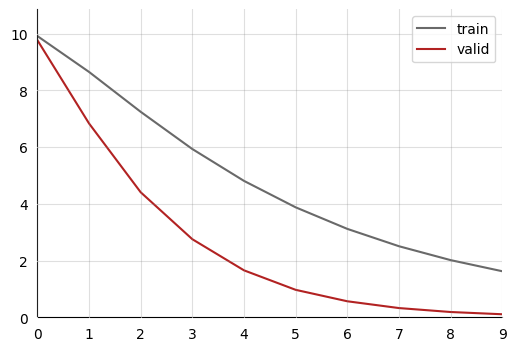

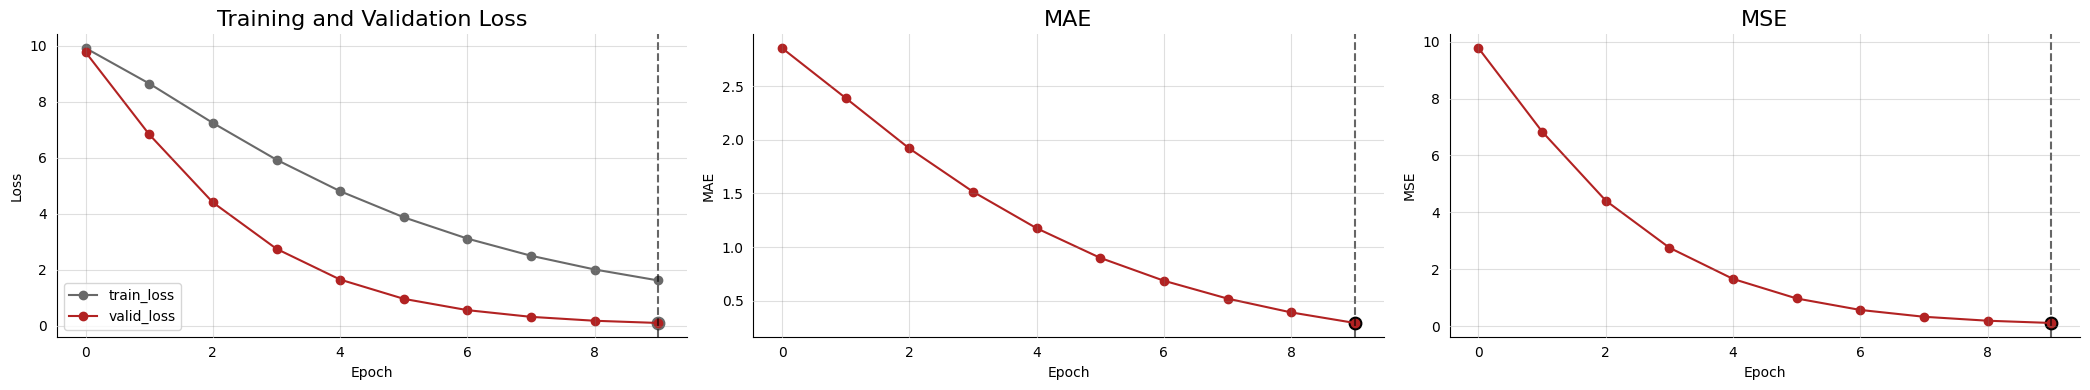

In [ ]:
set_backend("fastai")
learn = synth_learner(metrics=[MAEMetric, MSEMetric],cbs=[MeanLossGraphCallback(minimize_metrics=True, orientation="horizontal")])
learn.fit(10)

In [ ]:
#| export
class ShowGraphCallback(FastaiShowGraphCallback):

    def __init__(self, *args, style=bonsai_style, **kwargs):
        super().__init__(*args, **kwargs)
        self.style = style

    def __call__(self, *args, **kwargs):

        ctx = plt.rc_context(self.style) if self.style else nullcontext()

        with ctx:
            return super().__call__(*args, **kwargs)

epoch,train_loss,valid_loss,time
0,5.591940,5.799202,00:00
1,4.971397,4.329974,00:00
2,4.253227,2.991731,00:00
3,3.559486,1.999022,00:00
4,2.942533,1.328792,00:00


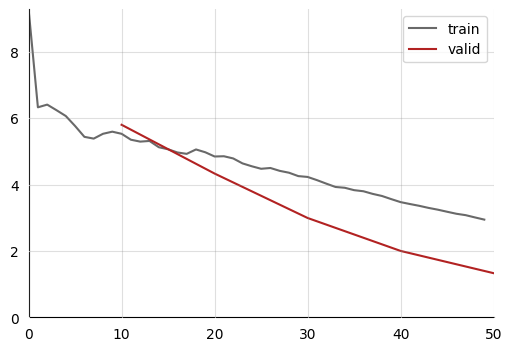

In [ ]:
learn = synth_learner(cbs=[ShowGraphCallback()])
learn.fit(5)

The `CSVLogger` is a tool for logging model training metrics to a CSV file, offering a permanent record of training history. This feature is especially useful for long-term experiments and fine-tuning, allowing you to track and analyze model performance over time.


In [ ]:
show_doc(CSVLogger)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/progress.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### CSVLogger

```python

def CSVLogger(
    fname:str='history.csv', append:bool=False
):


```

*Log the results displayed in `learn.path/fname`*

In [ ]:
#| export
CSVLogger = CSVLogger

## Scheduling callbacks

Callback and helper functions to schedule hyper-parameters

In [ ]:
show_doc(ParamScheduler)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### ParamScheduler

```python

def ParamScheduler(
    scheds
):


```

*Schedule hyper-parameters according to `scheds`*

In [ ]:
#| export
ParamScheduler = ParamScheduler

`scheds` is a dictionary with one key for each hyper-parameter you want to schedule, with either a scheduler or a list of schedulers as values (in the second case, the list must have the same length as the the number of parameters groups of the optimizer).

In [ ]:
show_doc(SchedCos)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedCos

```python

def SchedCos(
    start, end
):


```

*Cosine schedule function from `start` to `end`*

In [ ]:
#| export
SchedCos = SchedCos

In [ ]:
show_doc(SchedExp)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedExp

```python

def SchedExp(
    start, end
):


```

*Exponential schedule function from `start` to `end`*

In [ ]:
#| export
SchedExp = SchedExp

In [ ]:
show_doc(SchedLin)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedLin

```python

def SchedLin(
    start, end
):


```

*Linear schedule function from `start` to `end`*

In [ ]:
#| export
SchedLin = SchedLin

In [ ]:
show_doc(SchedNo)

---

[source](https://github.com/fastai/fastai/blob/main/fastai/callback/schedule.py#LNone){target="_blank" style="float:right; font-size:smaller"}

### SchedNo

```python

def SchedNo(
    start, end
):


```

*Constant schedule function with `start` value*

In [ ]:
#| export
SchedNo = SchedNo

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()